In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
%matplotlib inline
pd.set_option('display.max_columns', None)

In [4]:
df = pd.read_csv("../../../Day1/amz_uk_price_prediction_dataset.csv")

In [5]:
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [56]:
# Check if the data set has NaN values
df.isna().sum()

uid                  0
asin                 0
title                0
stars                0
reviews              0
price                0
isBestSeller         0
boughtInLastMonth    0
category             0
dtype: int64

In [7]:
df.columns

Index(['uid', 'asin', 'title', 'stars', 'reviews', 'price', 'isBestSeller',
       'boughtInLastMonth', 'category'],
      dtype='object')

### Part 1: Understanding Product Categories
**Business Question**: What are the most popular product categories on Amazon UK, and how do they compare in terms of listing frequency?

1. **Frequency Tables**:
    - Generate a frequency table for the product `category`.
    - Which are the top 5 most listed product categories?

In [6]:
frequency_table = df.category.value_counts()
frequency_table

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
                                           ...  
Alexa Built-In Devices                       107
Motorbike Chassis                            107
Plugs                                        107
Smart Home Security & Lighting               104
Smart Speakers                                54
Name: count, Length: 296, dtype: int64

The 5 most listed categories are: 

In [ ]:
print(f"The 5 most listed categories are: {frequency_table[:5]}")

The 5 most listed categories are: category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Name: count, dtype: int64


2. **Visualizations**:
    - Display the distribution of products across different categories using a bar chart. *If you face problems understanding the chart, do it for a subset of top categories.*
    - For a subset of top categories, visualize their proportions using a pie chart. Does any category dominate the listings?

C:\Users\vince\AppData\Local\Temp\ipykernel_8288\2877298607.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(frequency_table, palette = "magma", legend=True)


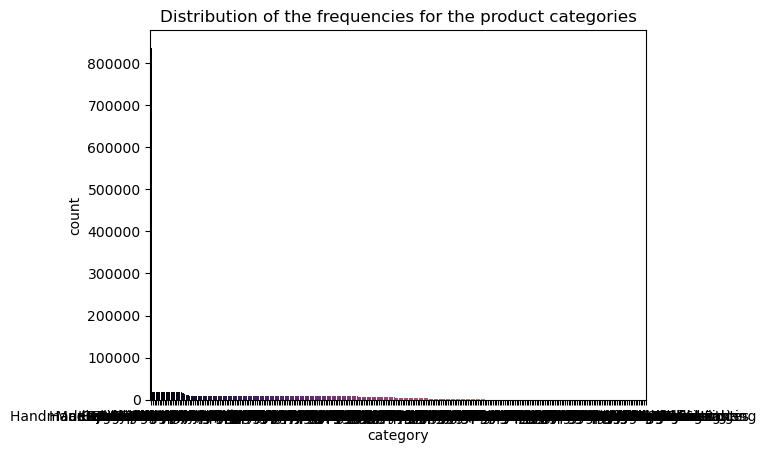

In [ ]:
sns.barplot(frequency_table, palette = "magma", legend=True)
plt.title("Distribution of the frequencies for the product categories")
plt.show()

C:\Users\vince\AppData\Local\Temp\ipykernel_27440\1021978372.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(frequency_table, palette = "magma", legend=True)


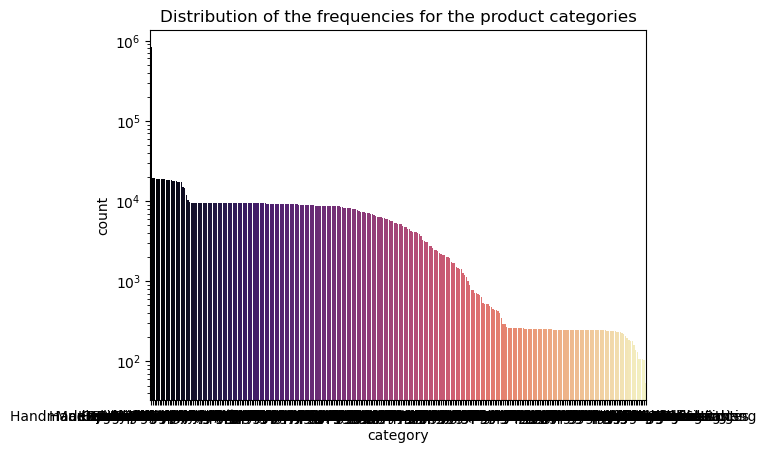

In [23]:
sns.barplot(frequency_table, palette = "magma", legend=True)
plt.title("Distribution of the frequencies for the product categories")
# Set a log scaling for better visualization
plt.yscale('log')
plt.show()

This view gives us a better representation of the frequency distribution for all categories. the first category is almost 2 order of magnitude higher than all other categories. The xlabels should be removed for sake of clarity, there are too many long label overlaping for a good reading. One solution would be to only show the label for specific categories or only visualize a portion of the data set and not all of it.

C:\Users\vince\AppData\Local\Temp\ipykernel_27440\3946109402.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(frequency_table[:5], palette = "magma")


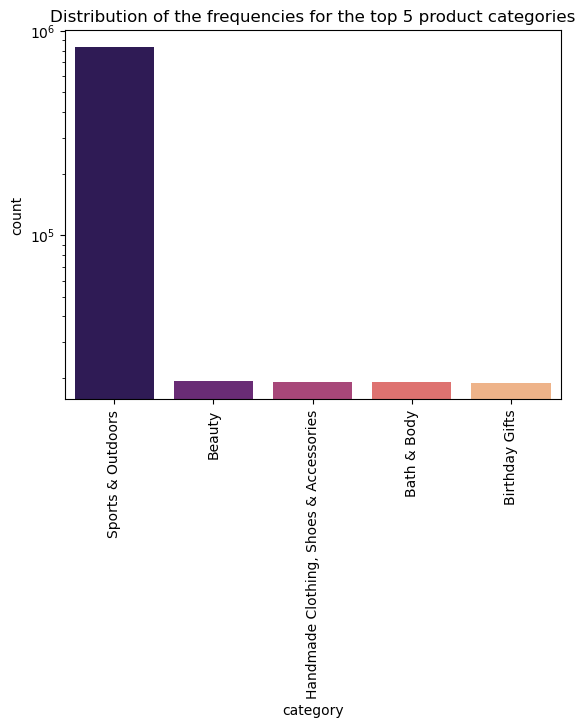

In [22]:
# We represent the same graph only for the top 5 categories:
sns.barplot(frequency_table[:5], palette = "magma")
plt.title("Distribution of the frequencies for the top 5 product categories")
plt.xticks(rotation=90)
# Set a log scaling for better visualization
plt.yscale('log')
plt.show()

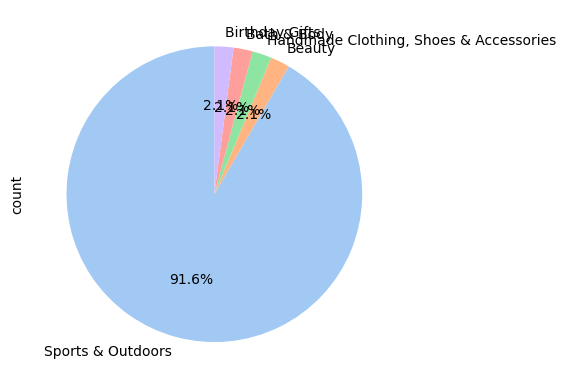

In [ ]:
frequency_table[:5].plot.pie(autopct="%1.1f%%", startangle=90, colors=sns.color_palette("pastel"))

plt.show()

The **Sport & Outdoors** category dominates the top 5 with almost 92% of the total frequencies, the rest is splitted almost equally between the 4 other categories(around 2.1% each).

### Part 2: Delving into Product Pricing

**Business Question**: How are products priced on Amazon UK, and are there specific price points or ranges that are more common?

1. **Measures of Centrality**:
    - Calculate the mean, median, and mode for the `price` of products.
    - What's the average price point of products listed? How does this compare with the most common price point (mode)?

In [ ]:
print(f'The Mean is: {df.price.mean():.2f} £')
print(f'The Median is: {df.price.median():.2f} £')
print(f'The Mode is: {df.price.mode()} £')

The Mean is: 89.24 pounds
The Median is: 19.09 pounds
The Mode is: 0    9.99
Name: price, dtype: float64 pounds


The average falls at 89.24 pounds while the mode is at 9.99 £. The median shows that half the values are under or equal to 19.09 £. The mode indicates that the most frequent price is 9.99 £. Knowing this, the average is still much higher at 89.24 pounds indicating that a lot of product are sold with much higher price to be able to drag the average so far from the median and mode.

2. **Measures of Dispersion**:
    - Determine the variance, standard deviation, range, and interquartile range for product `price`.
    - How varied are the product prices? Are there any indicators of a significant spread in prices?

In [97]:
print(f'The Variance is: {df.price.var():.2f} £')
print(f'The Standard Deviation is: {df.price.std():.2f} £')
print(f'The Range is: {df.price.max()-df.price.min()} £')

The Variance is: 119445.49 £
The Standard Deviation is: 345.61 £
The Range is: 100000.0 £


The price range is 100 000 £ showing a large spread of the prices. The variance is even greater than the range indicating an even stronger spreading of the data from the average. The standard deviation of about 345 £ also indicating a wide spread in prices. This confirms the hypothesis previously made with an average much higher than the median and mode. The large spread of the prices drag the average higher.

3. **Visualizations**:
    - Is there a specific price range where most products fall? Plot a histogram to visualize the distribution of product prices. *If its hard to read these diagrams, think why this is, and explain how it could be solved.*.
    - Are there products that are priced significantly higher than the rest? Use a box plot to showcase the spread and potential outliers in product pricing. 

In [7]:
frequency_table_price = df.price.value_counts().head(10).reset_index()
frequency_table_price.columns = ["price","counts"]
frequency_table_price

,price,counts
0,9.99,48922
1,12.99,38823
2,8.99,34058
3,7.99,33632
4,14.99,32570
5,6.99,31948
6,5.99,27818
7,19.99,27436
8,11.99,25488
9,10.99,25172


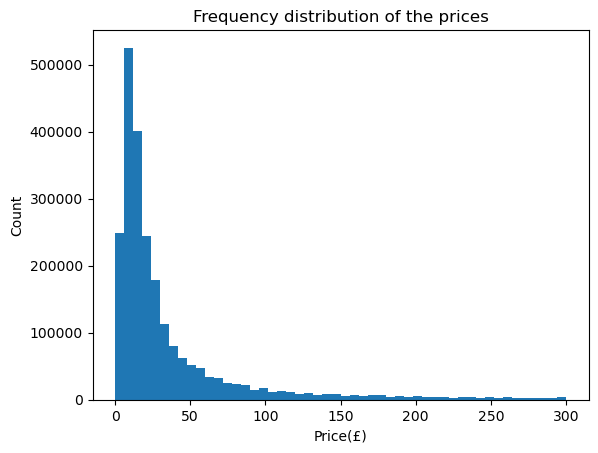

In [9]:
plt.hist(df[df['price'] <= 300]['price'], bins=50)
plt.title('Frequency distribution of the prices')
plt.xlabel("Price(£)")
plt.ylabel('Count')
plt.show()

C:\Users\vince\AppData\Local\Temp\ipykernel_12324\274695953.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df.price, palette = "Set2", linewidth = 2.5, log_scale=True)


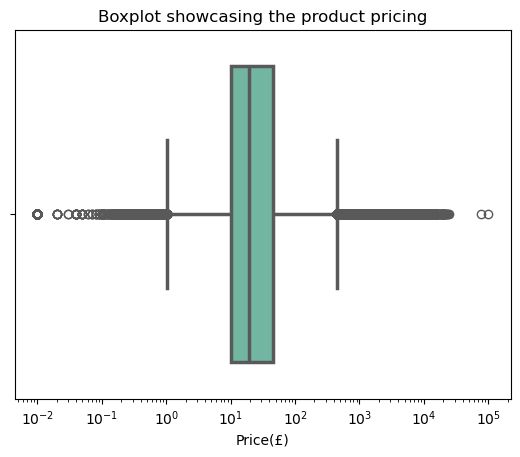

In [11]:
sns.boxplot(x=df.price, palette = "Set2", linewidth = 2.5, log_scale=True)
plt.title('Boxplot showcasing the product pricing')
plt.xlabel("Price(£)")
plt.show()

The box plot clearly shows that there are outliers with prices around up to 100000 £ ! the log10 scaling also highlights the outliers close to 0 (10**-2).

### Part 3: Unpacking Product Ratings

**Business Question**: How do customers rate products on Amazon UK, and are there any patterns or tendencies in the ratings?

1. **Measures of Centrality**:
    - Calculate the mean, median, and mode for the `rating` of products.
    - How do customers generally rate products? Is there a common trend?

In [140]:
print(f'The Mean is: {df.stars.mean():.2f} stars')
print(f'The Median is: {df.stars.median():.2f} stars')
print(f'The Mode is: {df.stars.mode()} stars')

The Mean is: 2.15 stars
The Median is: 0.00 stars
The Mode is: 0    0.0
Name: stars, dtype: float64 stars


The median is at 0 stars meaning that 50% of the customers either don't rate the products (if Amazon counts no rating = 0 stars) or leave a rating of 0 stars. The average lay at 2.15 stars which is a bit below the average value of 2.5 with 5 stars being the highest rating possible. The trend seems to be that half of the people don't rate the products (or leave a bad rating of 0 stars).

2. **Measures of Dispersion**:
    - Determine the variance, standard deviation, and interquartile range for product `rating`.
    - Are the ratings consistent, or is there a wide variation in customer feedback?

In [141]:
print(f'The Variance is: {df.stars.var():.2f} stars')
print(f'The Standard Deviation is: {df.stars.std():.2f} stars')
print(f'The Interquartile range is: {df.stars.quantile(0.75)-df.stars.quantile(0.25)} stars')

The Variance is: 4.82 stars
The Standard Deviation is: 2.19 stars
The Interquartile range is: 4.4 stars


The large variance of 4.82 stars shows that the ratings are very spread from 0 to 5 stars. The Interquartile range shows that around 25% of the people rate above 4.4 stars. This confirms the large spread of the ratings.

3. **Shape of the Distribution**:
    - Calculate the skewness and kurtosis for the `rating` column. 
    - Are the ratings normally distributed, or do they lean towards higher or lower values?

In [142]:
print(f'The skewness is: {df.stars.skew():.2f} stars')

The skewness is: 0.08 stars


The skewness is slightly positive suggesting that the ratings lean toward higher values.

4. **Visualizations**:
    - Plot a histogram to visualize the distribution of product ratings. Is there a specific rating that is more common?

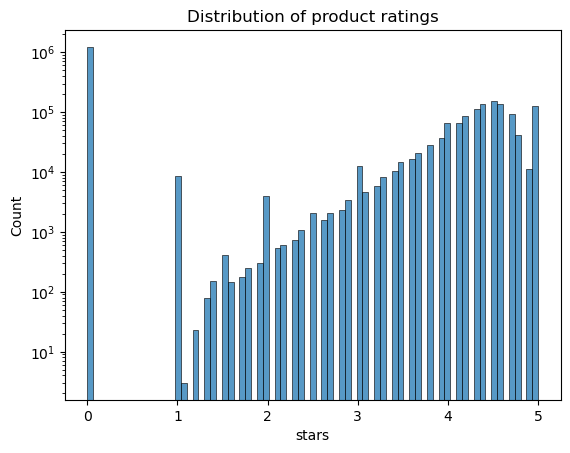

In [12]:
sns.histplot(df.stars)
# Set a log10 scaling on count for better representation
plt.yscale('log')
plt.title('Distribution of product ratings')
plt.show()

In [191]:
df.stars.value_counts().head(1)

stars
0.0    1225641
Name: count, dtype: int64

We can clearly see from the histogram that the 0 rating is the most common among the data set provided with 1225641 counts.